In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import os
# XGBoost
from xgboost import XGBRegressor
# LightGBM
from lightgbm import LGBMRegressor
# CatBoost
from catboost import CatBoostRegressor
# Gradient Boosting from scikit-learn
from sklearn.ensemble import GradientBoostingRegressor
# AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor
pd.set_option("display.max_columns",None)
%matplotlib inline

In [2]:
df=pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_training.csv")

In [3]:
df.drop(columns=["Id","id"],axis=1,inplace=True)

In [4]:
df.head()

,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


In [5]:
df.shape

(750, 25)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sales                      750 non-null    float64
 1   Web_GRP                    750 non-null    int64  
 2   TV_GRP                     750 non-null    int64  
 3   Facebook_GRP               750 non-null    int64  
 4   Tone_of_Ad                 750 non-null    object 
 5   No_of_Web_Banners          750 non-null    int64  
 6   Weather                    750 non-null    object 
 7   Avg_Temperature            750 non-null    int64  
 8   No_of_Rabbits              750 non-null    int64  
 9   Network_Five_G             750 non-null    int64  
 10  No_of_iPhone_14_Sold       750 non-null    int64  
 11  No_of_Big_Cities           750 non-null    int64  
 12  Health_Index               750 non-null    int64  
 13  Sustainability_Index       750 non-null    int64  

In [7]:
df.isnull().sum()

sales                        0
Web_GRP                      0
TV_GRP                       0
Facebook_GRP                 0
Tone_of_Ad                   0
No_of_Web_Banners            0
Weather                      0
Avg_Temperature              0
No_of_Rabbits                0
Network_Five_G               0
No_of_iPhone_14_Sold         0
No_of_Big_Cities             0
Health_Index                 0
Sustainability_Index         0
Choc_Capital_Distance        0
No_of_Competitors            0
Import_Regulations           0
Time_in_Region               0
Percent_Internet_Access      0
Percent_Uni_Degrees          0
Percent_Unemployed           0
Gender                       0
Coffee_Consumption           0
Avg_No_of_Cust_Complaints    0
Avg_Customer_Age             0
dtype: int64

In [8]:
df.describe()

,sales,Web_GRP,TV_GRP,Facebook_GRP,No_of_Web_Banners,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Avg_No_of_Cust_Complaints,Avg_Customer_Age
count,750.000000,750.000000,750.00000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,299324.408707,99.032000,50.02400,75.405333,2.998667,19.641333,99.804000,0.592000,74.733333,4.973333,49.765333,30.642667,4821.108000,4.980000,0.782667,70.066667,49.870667,33.000000,7.624000,0.485333,241.108000,48.293333
std,112738.241817,2.604615,7.50341,9.797876,1.400457,5.626862,6.714887,0.491791,13.860292,1.033140,14.899517,12.179797,2904.278332,1.015698,0.412707,16.076032,8.093946,4.111594,5.064598,0.500118,15.065511,17.465414
min,49989.270000,90.000000,21.00000,46.000000,1.000000,10.000000,73.000000,0.000000,35.000000,1.000000,1.000000,-5.000000,4.000000,1.000000,0.000000,27.000000,16.000000,19.000000,1.000000,0.000000,198.000000,18.000000
25%,215145.250000,97.000000,45.00000,69.000000,2.000000,15.000000,95.000000,0.000000,66.000000,4.000000,40.000000,22.000000,2276.250000,4.000000,1.000000,59.000000,44.000000,30.000000,3.250000,0.000000,231.000000,34.000000
50%,288297.420000,99.000000,50.00000,76.000000,3.000000,20.000000,100.000000,1.000000,74.000000,5.000000,50.000000,31.000000,4722.000000,5.000000,1.000000,70.000000,50.000000,33.000000,7.000000,0.000000,241.000000,48.000000
75%,372411.312500,101.000000,55.00000,82.000000,4.000000,24.000000,104.000000,1.000000,84.750000,6.000000,60.000000,39.000000,7348.000000,6.000000,1.000000,81.000000,55.000000,36.000000,10.000000,1.000000,251.000000,63.000000
max,740551.940000,109.000000,73.00000,101.000000,5.000000,29.000000,120.000000,1.000000,124.000000,8.000000,96.000000,66.000000,9988.000000,8.000000,1.000000,119.000000,75.000000,46.000000,20.000000,1.000000,297.000000,78.000000


In [9]:
df.head()

,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


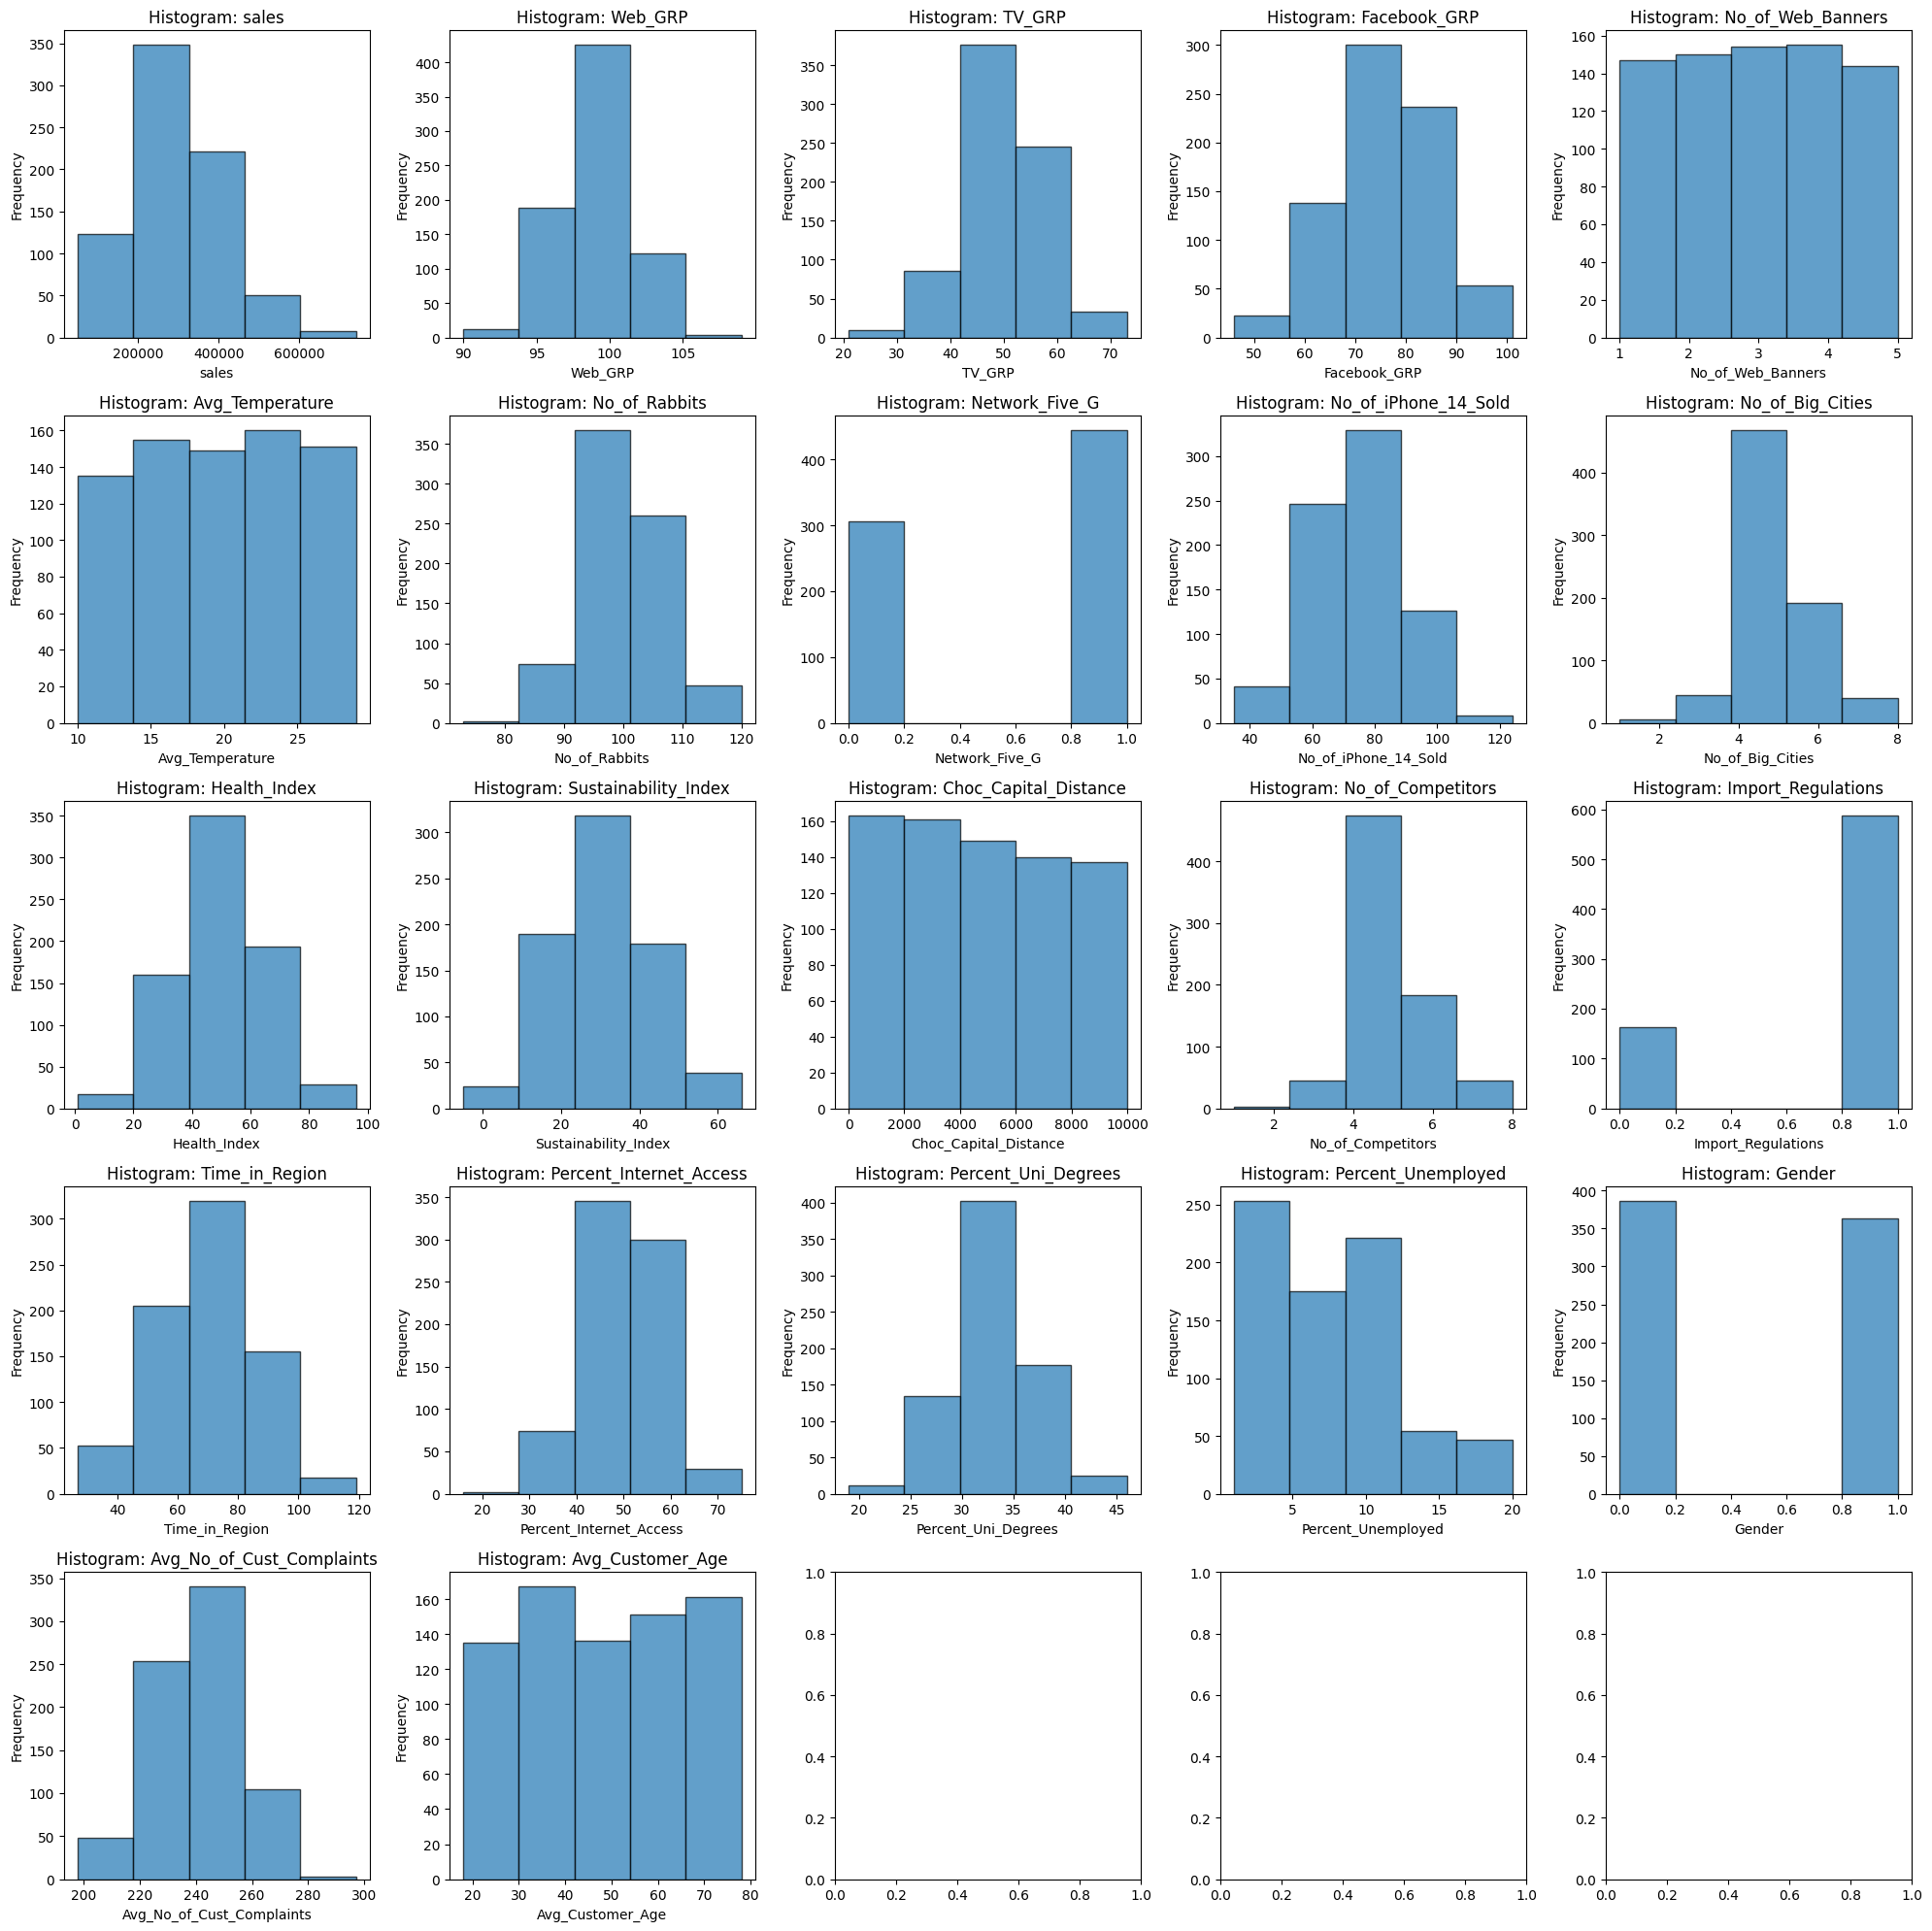

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()
for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=5, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Histogram: {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

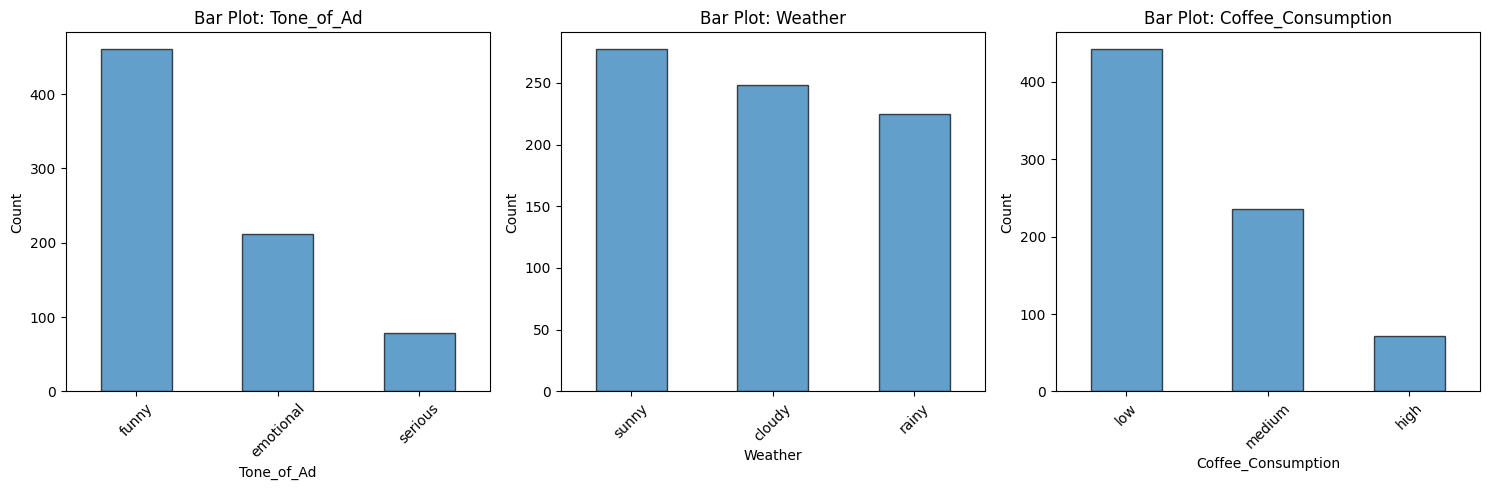

In [11]:
categorical_cols = ['Tone_of_Ad', 'Weather', 'Coffee_Consumption']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Bar Plot: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

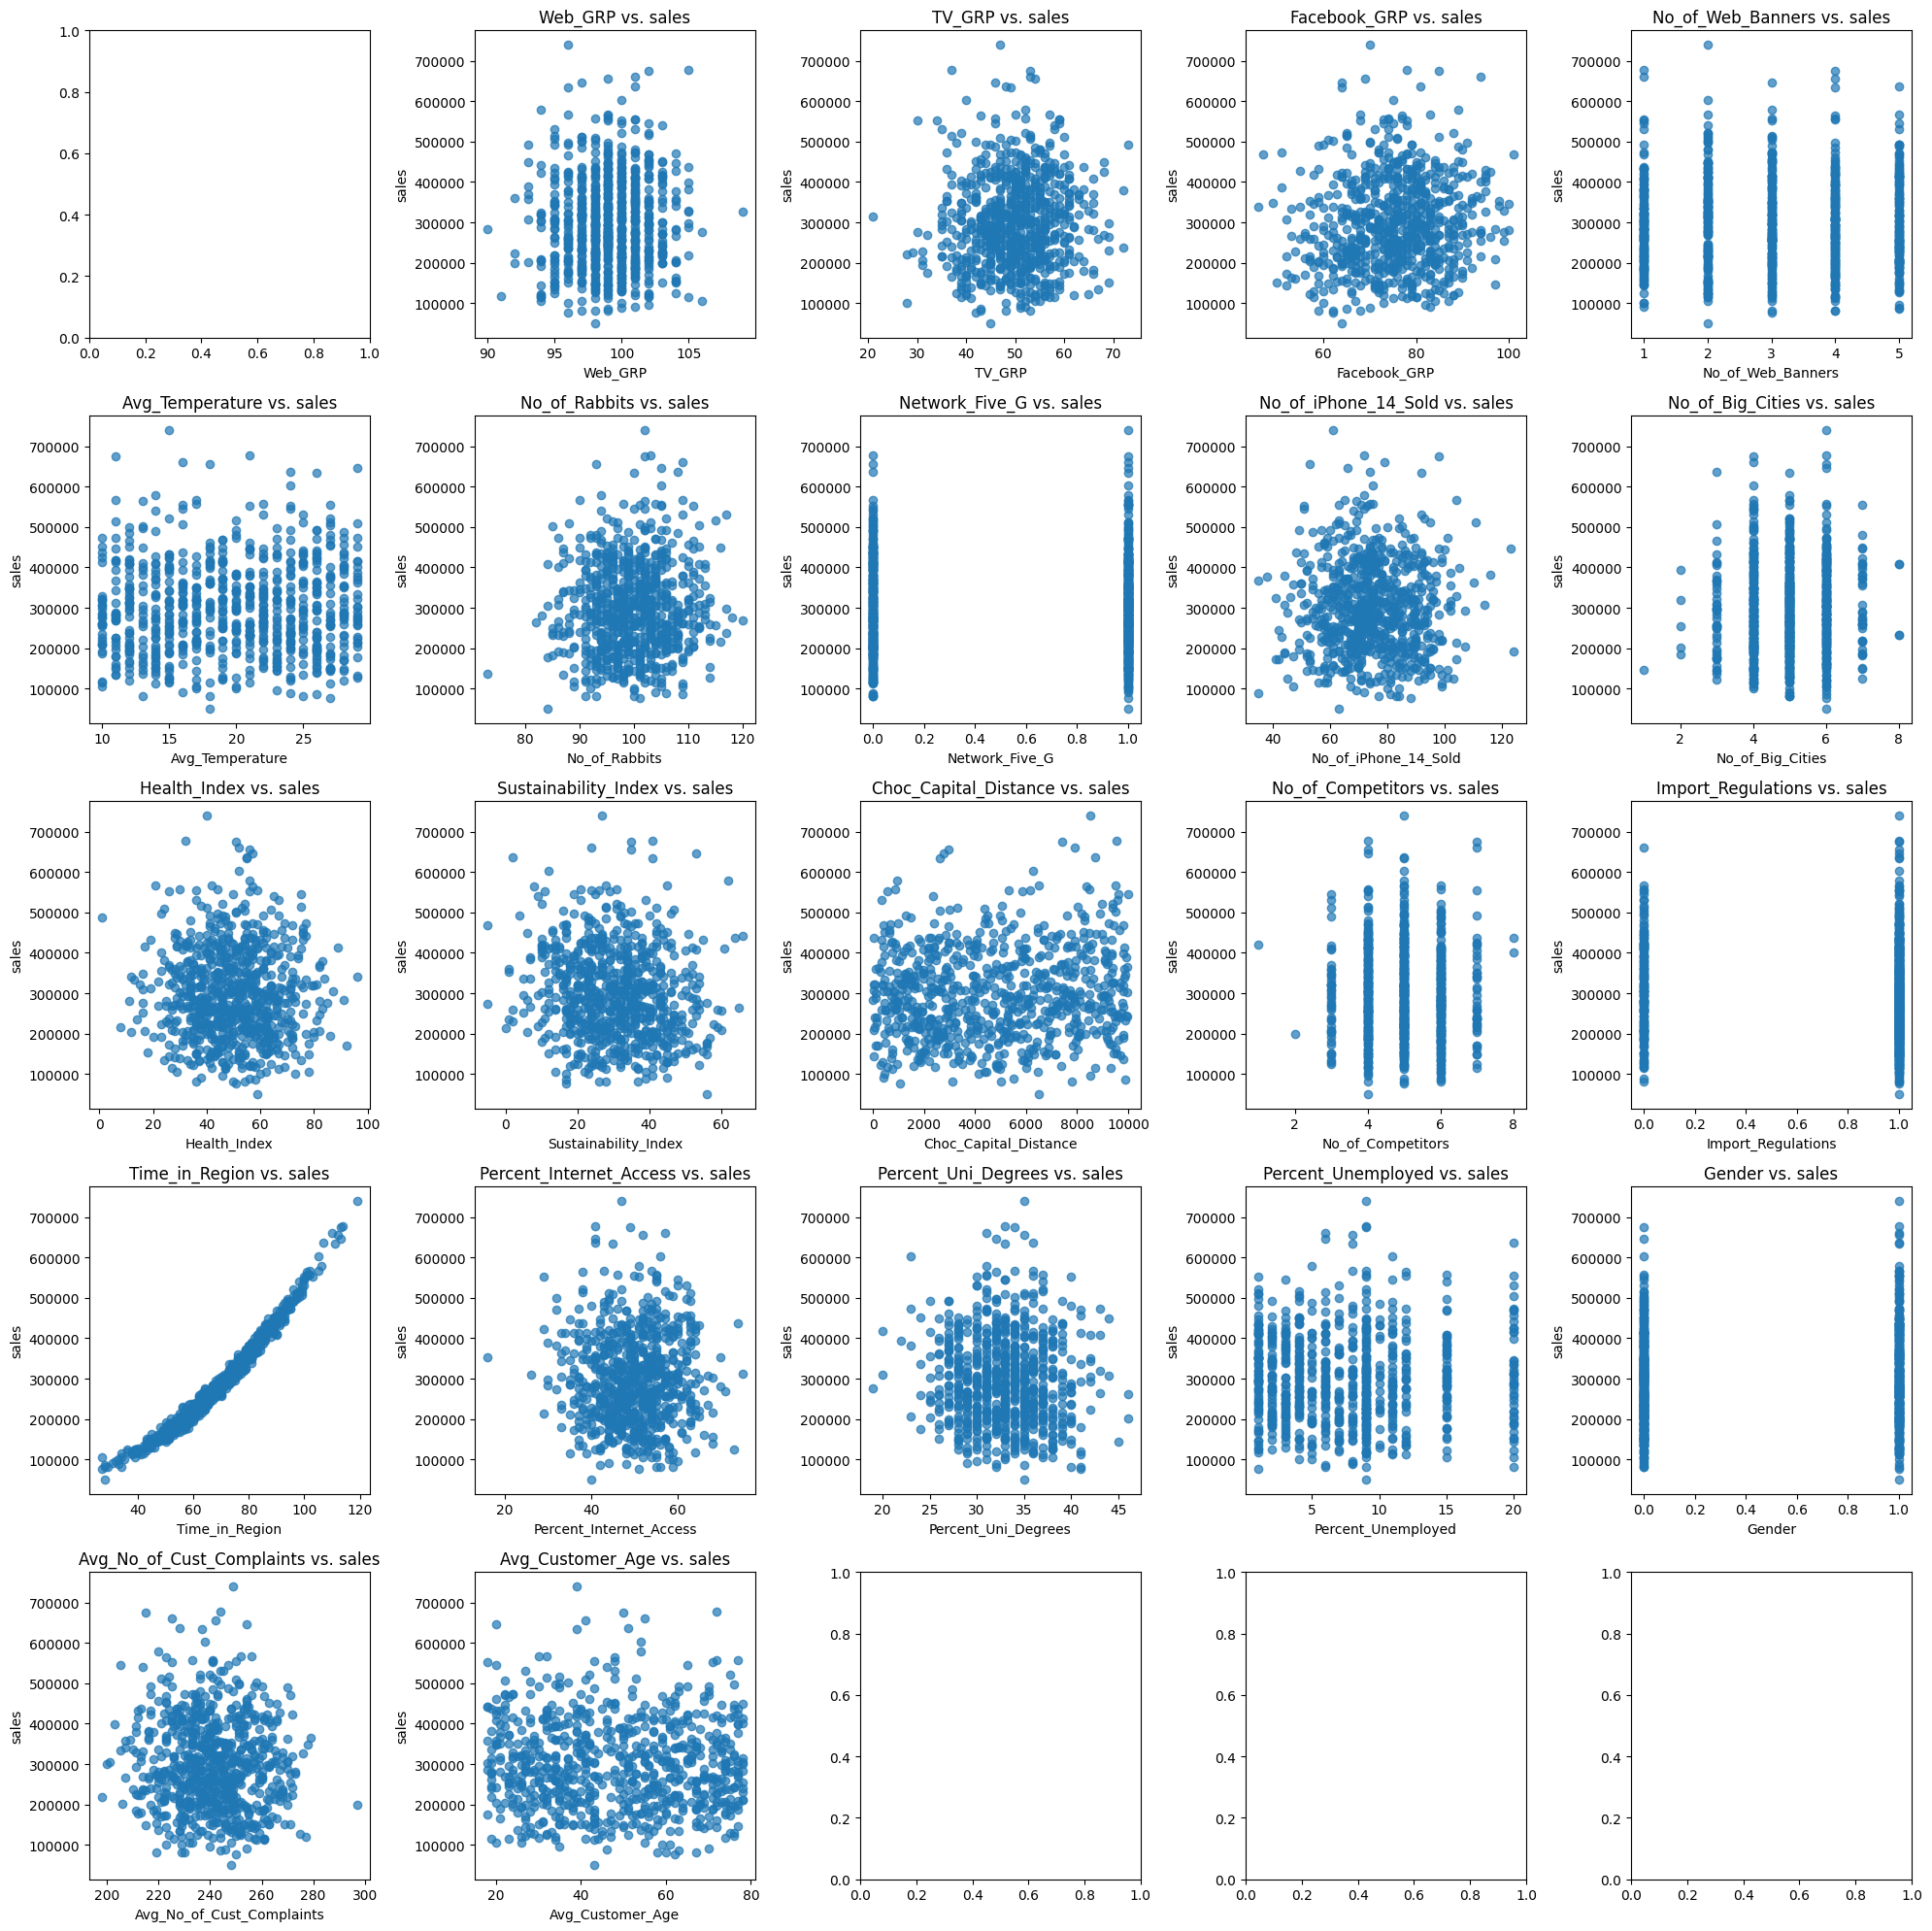

In [12]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()
sales_col = 'sales'
for idx, col in enumerate(numerical_cols):
    if col != sales_col and idx < len(axes):
        axes[idx].scatter(df[col], df[sales_col], alpha=0.7)
        axes[idx].set_title(f'{col} vs. {sales_col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(sales_col)
plt.tight_layout()
plt.show()

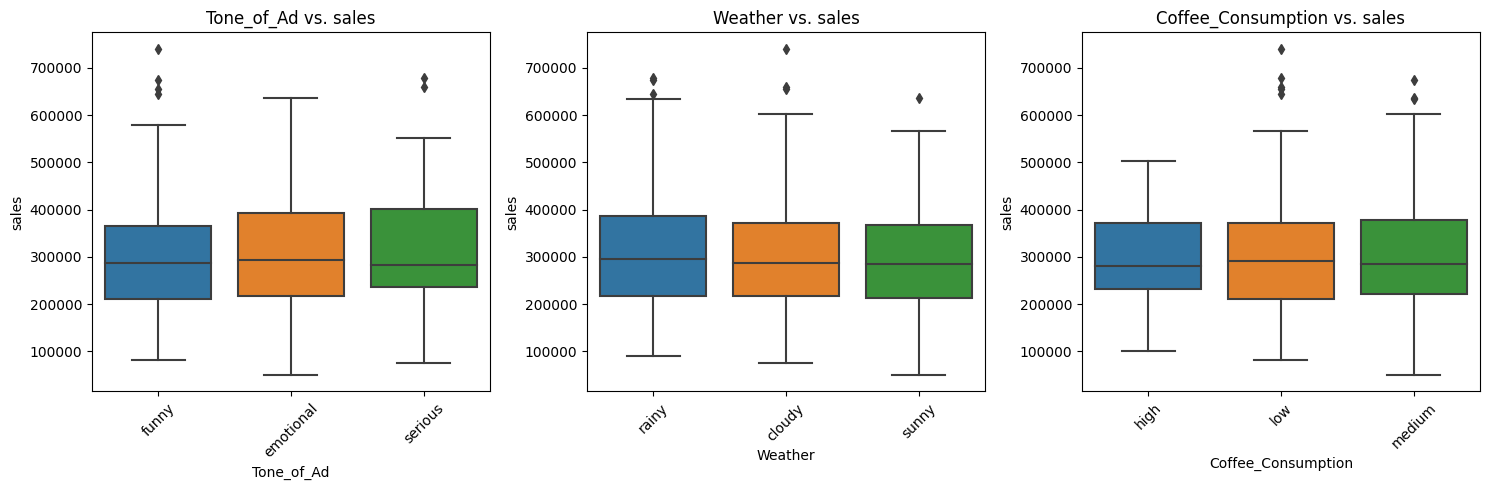

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y=sales_col, data=df, ax=axes[idx])
    axes[idx].set_title(f'{col} vs. {sales_col}')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


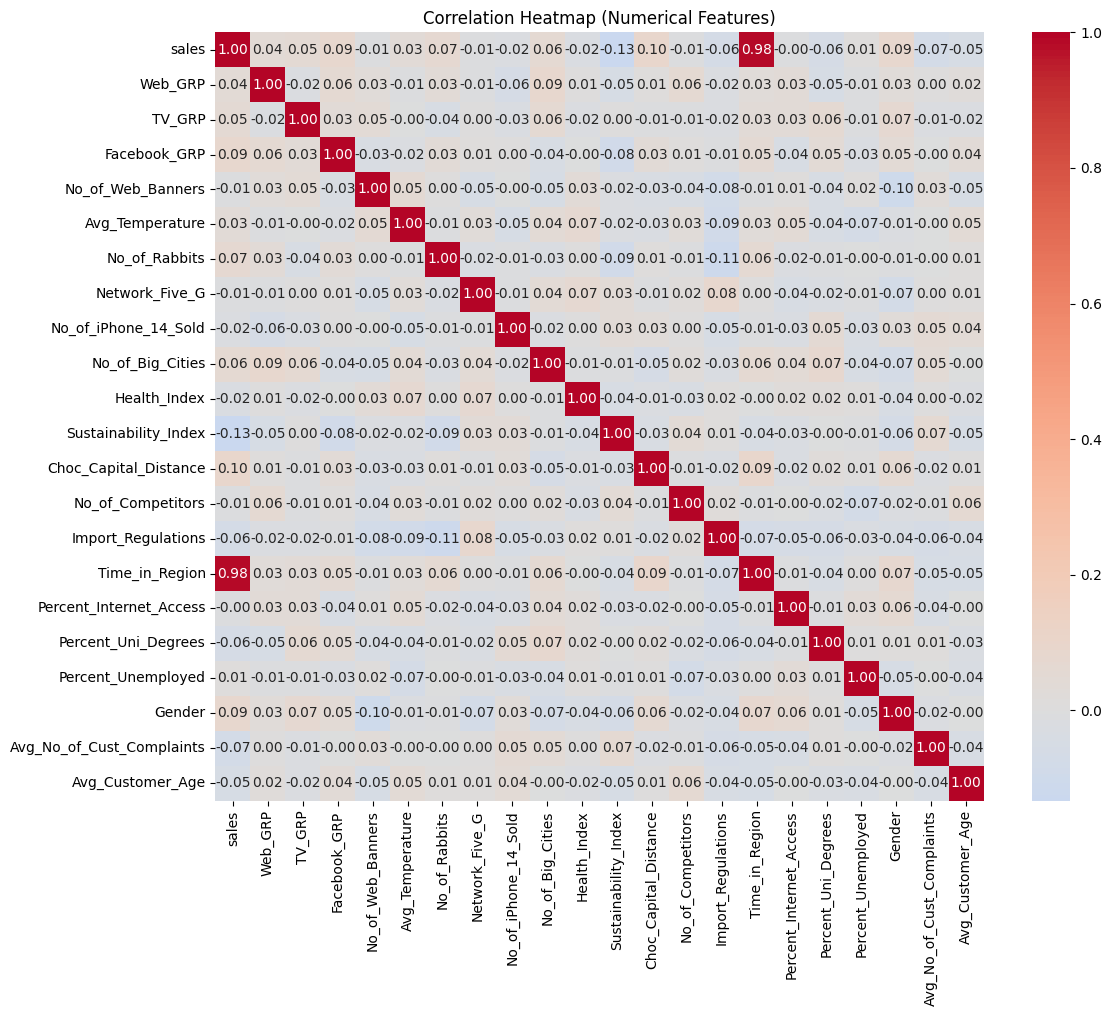

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

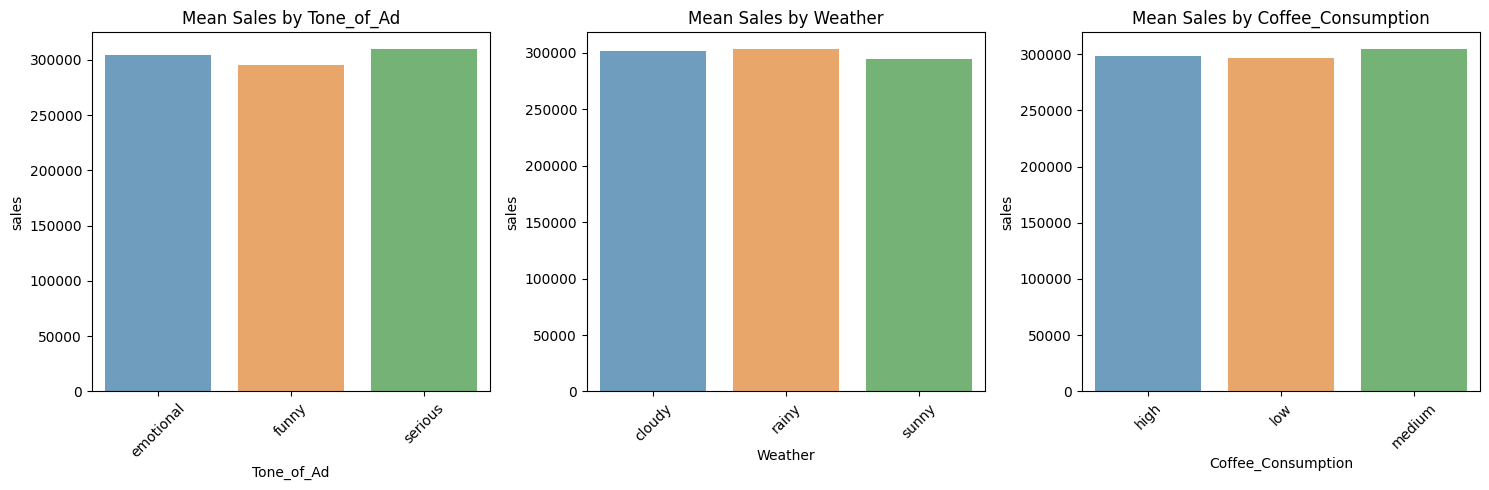

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df_grouped = df.groupby(col)['sales'].mean().reset_index()
    sns.barplot(x=col, y='sales', data=df_grouped, ax=axes[idx], alpha=0.7)
    axes[idx].set_title(f'Mean Sales by {col}')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

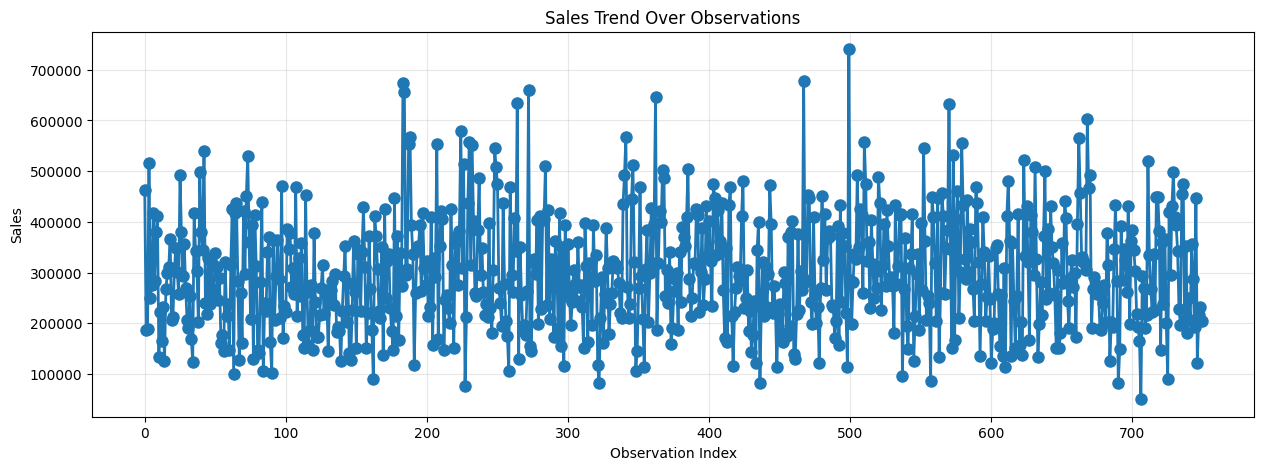

In [16]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['sales'], marker='o', linewidth=2, markersize=8)
plt.title('Sales Trend Over Observations')
plt.xlabel('Observation Index')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

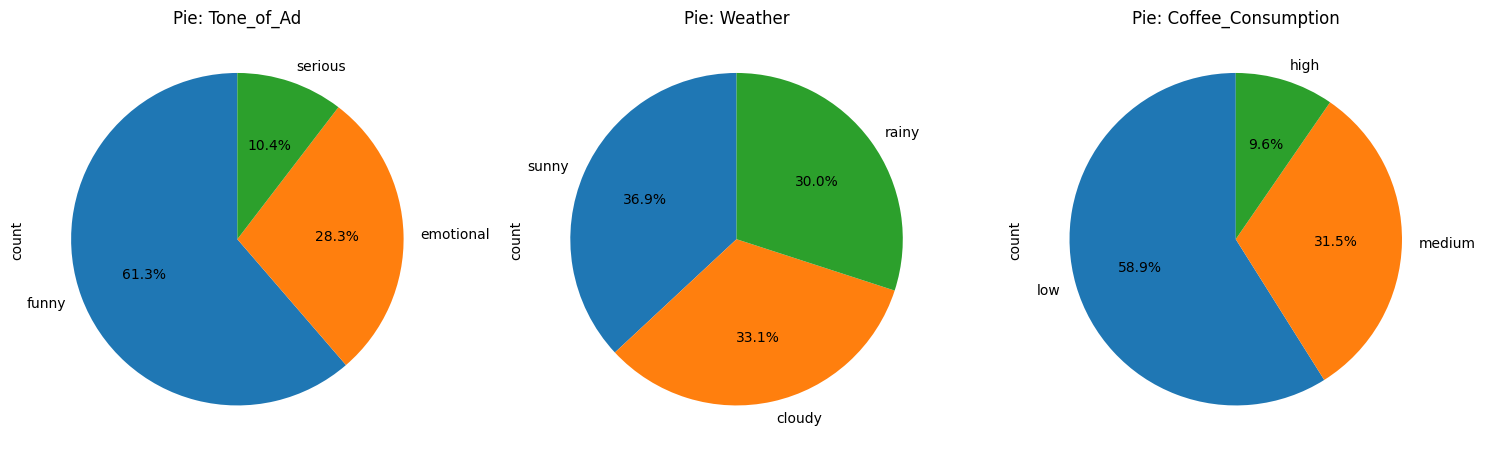

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='pie', ax=axes[idx], autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(f'Pie: {col}')
plt.tight_layout()
plt.show()

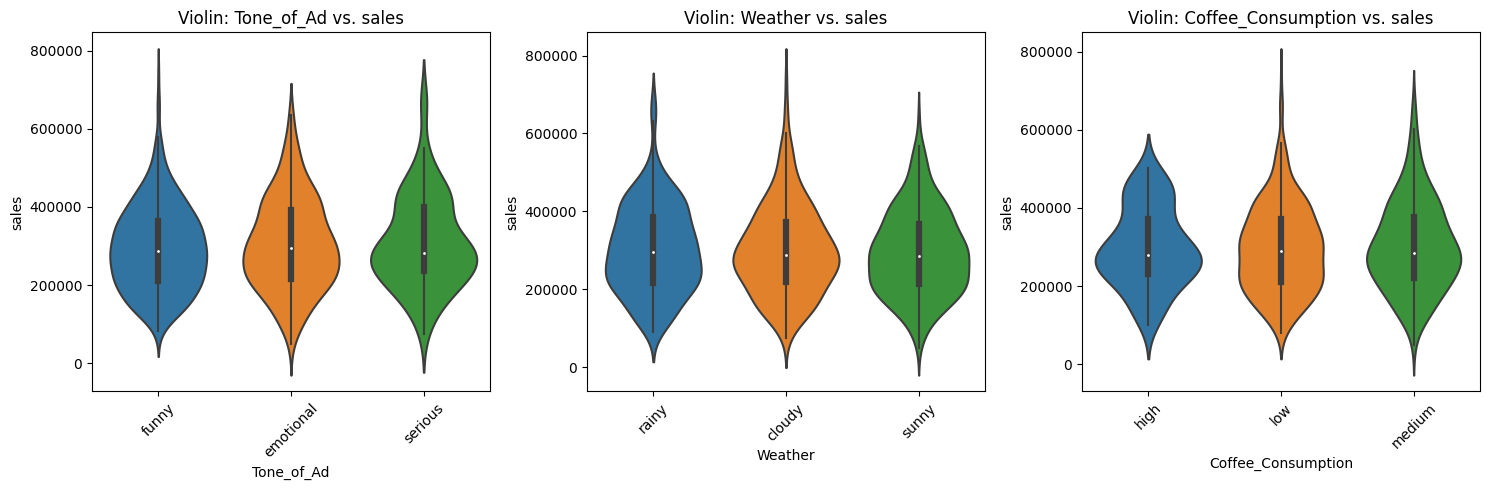

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    sns.violinplot(x=col, y=sales_col, data=df, ax=axes[idx])
    axes[idx].set_title(f'Violin: {col} vs. {sales_col}')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df.head()

,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


In [20]:
y = df["sales"]
X = df.drop(columns=["sales"],axis=1)

In [21]:
numeric_features = [
    "Web_GRP", "TV_GRP", "Facebook_GRP", "No_of_Web_Banners", "Avg_Temperature",
    "No_of_Rabbits", "No_of_iPhone_14_Sold", "No_of_Big_Cities",
    "Health_Index", "Sustainability_Index", "Choc_Capital_Distance",
    "No_of_Competitors", "Time_in_Region", "Percent_Internet_Access",
    "Percent_Uni_Degrees", "Percent_Unemployed", "Avg_No_of_Cust_Complaints",
    "Avg_Customer_Age"
]

categorical_features = ["Tone_of_Ad", "Weather"]
ordinal_features = ["Coffee_Consumption"]

binary_features = ["Network_Five_G", "Import_Regulations", "Gender"]

In [22]:
# Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_transformer = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=[["low", "medium", "high"]]))
])

binary_transformer = "passthrough" 

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X.shape

(750, 24)

In [25]:
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("bin", binary_transformer, binary_features)])


model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", GradientBoostingRegressor())])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Web_GRP', 'TV_GRP',
                                                   'Facebook_GRP',
                                                   'No_of_Web_Banners',
                                                   'Avg_Temperature',
                                                   'No_of_Rabbits',
                                                   'No_of_iPhone_14_Sold',
                                                   'No_of_Big_Cities',
                                                   'Health_Index',
                                                   'Sustainability_Index',
                                                   'Choc_Capital_Dista...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Tone_of_Ad', 'Weather']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['Coffee_Consumption']),
                                                 ('bin', 'passthrough',
                                                  ['Network_Five_G',
                                                   'Import_Regulations',
                                                   'Gender'])])),
                ('regressor', GradientBoostingRegressor())])

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

preds = model.predict(X_valid)

# Metrics
mae = mean_absolute_error(y_valid, preds)
mse = mean_squared_error(y_valid, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, preds)
mape = mean_absolute_percentage_error(y_valid, preds)

print("Validation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.4f}")


Validation Metrics:
MAE  : 5446.0066
MSE  : 97875928.1250
RMSE : 9893.2264
R²   : 0.9929
MAPE : 0.0191


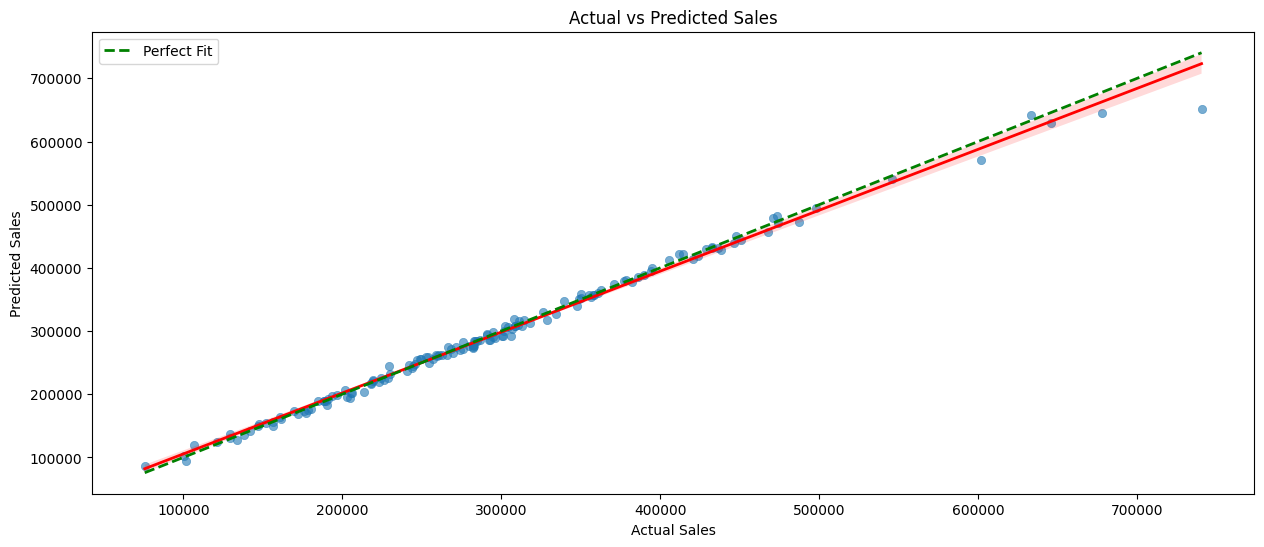

In [27]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=y_valid, y=preds, alpha=0.6, edgecolor=None)
sns.regplot(x=y_valid, y=preds, scatter=False, color="red", line_kws={"linewidth":2})

min_val = min(y_valid.min(), preds.min())
max_val = max(y_valid.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color="green", linestyle="--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

In [28]:
test_df=pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_test.csv")

In [29]:
test_df.head()

,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
0,1,97,47,76,serious,5,sunny,29,93,0,55,5,27,27,154,4,0,76,48,27,9,1,low,242,43,1
1,4,95,53,78,emotional,5,sunny,19,95,0,74,6,49,42,3409,6,1,52,52,37,1,1,low,250,18,4
2,6,97,53,67,emotional,3,sunny,24,92,1,62,4,48,54,4380,6,0,94,42,27,12,1,medium,232,50,6
3,15,96,45,70,serious,4,cloudy,19,102,1,66,4,57,37,9318,3,1,69,56,31,11,0,medium,223,65,15
4,18,101,36,93,funny,5,rainy,26,86,0,63,7,53,25,1232,6,1,66,53,38,3,0,medium,238,18,18


In [30]:
X_test = test_df.drop(columns=["Id","id"],errors="ignore")
test_predictions = model.predict(X_test)


In [31]:
submission = pd.DataFrame({"Id": test_df["Id"],"Expected": test_predictions})

In [32]:
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

Submission file saved!


In [33]:
sub_df=pd.read_csv("/kaggle/working/submission.csv")

In [34]:
sub_df.head()

,Id,Expected
0,1,337988.179075
1,4,169343.797003
2,6,470767.465838
3,15,269750.559700
4,18,264451.689231


In [35]:
df.head()

,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


In [36]:
y = df["sales"]
X = df.drop(columns=["sales"], errors="ignore")

numeric_features = [
    "Web_GRP", "TV_GRP", "Facebook_GRP", "No_of_Web_Banners",
    "Avg_Temperature", "No_of_Rabbits", "No_of_iPhone_14_Sold",
    "No_of_Big_Cities", "Health_Index", "Sustainability_Index",
    "Choc_Capital_Distance", "No_of_Competitors", "Time_in_Region",
    "Percent_Internet_Access", "Percent_Uni_Degrees", "Percent_Unemployed",
    "Avg_No_of_Cust_Complaints", "Avg_Customer_Age"
]
categorical_features = ["Tone_of_Ad", "Weather"]
ordinal_features = ["Coffee_Consumption"]
binary_features = ["Network_Five_G", "Import_Regulations", "Gender"]

In [37]:
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
X[categorical_features + ordinal_features] = X[categorical_features + ordinal_features].ffill()
X[binary_features] = X[binary_features].fillna(0)

X[numeric_features] = StandardScaler().fit_transform(X[numeric_features])
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

ordinal_encoder = OrdinalEncoder(categories=[["low","medium","high"]])
X[ordinal_features] = ordinal_encoder.fit_transform(X[ordinal_features].astype(str))

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(float)


In [38]:
X

,Web_GRP,TV_GRP,Facebook_GRP,No_of_Web_Banners,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,Tone_of_Ad_funny,Tone_of_Ad_serious,Weather_rainy,Weather_sunny
0,-0.012294,0.796969,-0.143528,0.715482,0.241622,-0.864925,1,-1.208091,-0.942740,1.761948,-0.381432,0.196011,1.004906,1,1.365260,0.881411,-0.243377,-0.123290,0,2.0,-0.405700,-1.621045,1.0,0.0,1.0,0.0
1,0.371896,0.396884,-0.143528,-0.713576,0.241622,0.029208,1,-1.641272,-0.942740,-0.252884,0.193674,-0.344242,-0.965498,1,-1.000084,-0.725800,0.243377,0.271871,0,0.0,0.324932,1.071784,0.0,0.0,1.0,0.0
2,0.756086,-0.803371,1.286307,0.715482,0.063784,-1.759058,0,-0.413928,-0.942740,0.888854,1.343885,-0.817997,0.019704,0,-0.875593,0.015990,-0.486754,-0.913614,1,0.0,0.258511,1.644726,0.0,0.0,0.0,0.0
3,1.140276,0.396884,-1.062708,-0.713576,0.063784,2.264542,0,-0.847108,0.025828,-0.790172,0.111516,0.079209,0.019704,0,1.738736,0.881411,0.973508,-0.716033,0,0.0,-1.136332,-0.761631,1.0,0.0,1.0,0.0
4,0.756086,-1.070094,-0.245659,1.430011,-1.003241,0.476275,0,-0.197338,0.025828,1.224660,0.686622,1.336125,0.019704,1,-0.253133,-0.478537,0.000000,-1.111194,0,0.0,-0.937068,-0.188689,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,-0.012294,0.396884,0.877782,0.000953,0.241622,0.327253,1,3.484694,0.025828,1.023176,1.097411,1.348874,0.019704,0,1.303014,0.263253,-0.973508,-1.308775,1,2.0,0.856300,1.415549,0.0,0.0,0.0,1.0
746,0.756086,1.597139,1.286307,0.000953,-1.358916,-0.864925,0,-0.269534,0.994397,-0.185723,-0.545748,0.006165,0.019704,1,-1.996019,0.386884,1.947016,0.271871,1,0.0,2.383985,-0.818925,1.0,0.0,1.0,0.0
747,-0.396484,-2.003626,-0.756314,0.000953,0.419460,1.519431,0,-1.135895,0.025828,0.687371,-0.134958,1.580066,1.004906,1,-0.626609,-1.220326,-0.486754,-1.111194,1,0.0,-1.003489,0.326959,0.0,0.0,0.0,1.0
748,-0.780674,0.130161,0.571389,-1.428106,0.419460,0.029208,0,-0.847108,0.025828,0.015760,0.686622,0.142262,0.019704,1,-0.502117,-0.849431,-0.973508,0.864614,0,2.0,-0.870647,-0.303277,0.0,0.0,0.0,1.0


In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [41]:
y_pred = model.predict(X_valid)
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2:", r2_score(y_valid, y_pred))

MAE: 5414.806647572426
RMSE: 9867.89784632786
R2: 0.9928964472803294


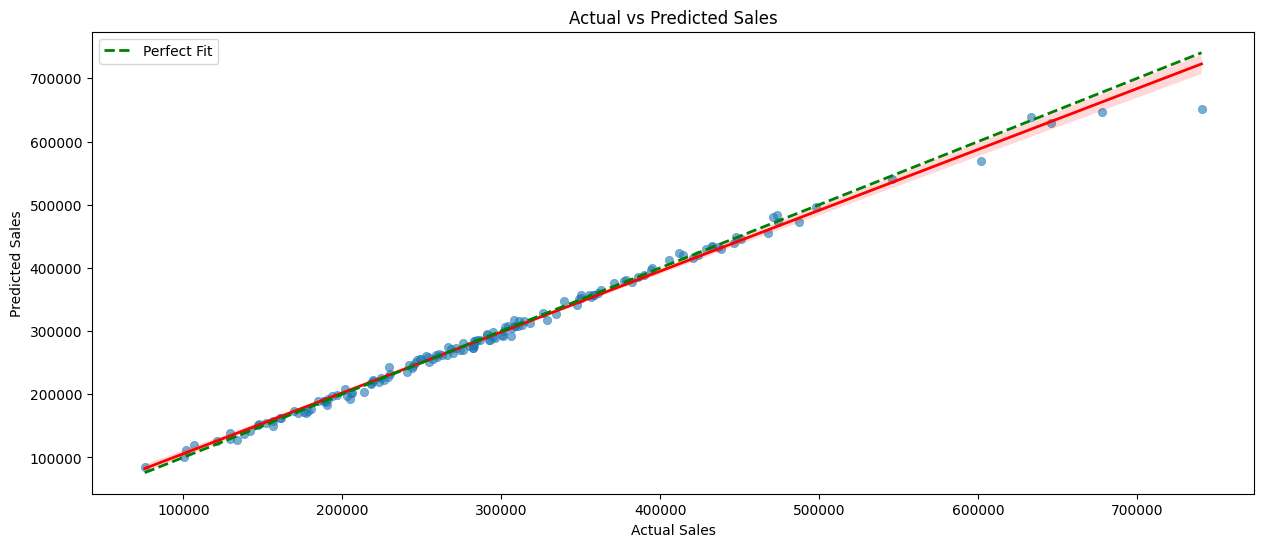

In [42]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=y_valid, y=y_pred, alpha=0.6, edgecolor=None)
sns.regplot(x=y_valid, y=y_pred, scatter=False, color="red", line_kws={"linewidth":2})

min_val = min(y_valid.min(), y_pred.min())
max_val = max(y_valid.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="green", linestyle="--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

In [43]:
test_df=pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_test.csv")

In [44]:
test_df.head()

,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
0,1,97,47,76,serious,5,sunny,29,93,0,55,5,27,27,154,4,0,76,48,27,9,1,low,242,43,1
1,4,95,53,78,emotional,5,sunny,19,95,0,74,6,49,42,3409,6,1,52,52,37,1,1,low,250,18,4
2,6,97,53,67,emotional,3,sunny,24,92,1,62,4,48,54,4380,6,0,94,42,27,12,1,medium,232,50,6
3,15,96,45,70,serious,4,cloudy,19,102,1,66,4,57,37,9318,3,1,69,56,31,11,0,medium,223,65,15
4,18,101,36,93,funny,5,rainy,26,86,0,63,7,53,25,1232,6,1,66,53,38,3,0,medium,238,18,18


In [45]:
X_test = test_df.drop(columns=["Id","id"], errors="ignore")
X_test[numeric_features] = X_test[numeric_features].fillna(X[numeric_features].median())
X_test[categorical_features + ordinal_features] = X_test[categorical_features + ordinal_features].ffill()
X_test[binary_features] = X_test[binary_features].fillna(0)

scaler = StandardScaler().fit(X[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[X.columns]

ordinal_encoder = OrdinalEncoder(categories=[["low","medium","high"]])
ordinal_encoder.fit(df[ordinal_features].astype(str))
X_test[ordinal_features] = ordinal_encoder.transform(X_test[ordinal_features].astype(str))
bool_cols = X_test.select_dtypes(include='bool').columns
X_test[bool_cols] = X_test[bool_cols].astype(float)

In [46]:
y_pred_test = model.predict(X_test)

# Create submission
submission = pd.DataFrame({"Id": test_df["Id"],"Expected": y_pred_test})

submission.to_csv("gb_submission.csv", index=False)

In [48]:
sub_gb=pd.read_csv("/kaggle/working/gb_submission.csv")
sub_gb.head()

,Id,Expected
0,1,644395.631697
1,4,644395.631697
2,6,644395.631697
3,15,643325.819277
4,18,643325.819277
